# Controlling Dobot

In [1]:
from dobot import Dobot
# fix permissions possibly:
#   sudo chmod o+rw /dev/ttyACM0
dobot = Dobot('/dev/ttyACM0', plot=True, debug=True)
dobot.pos

Board: FPGA
--=========--
Initializing accelerometers
Initializing with steps: 0 0 5304
Reading back what was set: (1, 0, 0, 5304)
Current estimated coordinates: (131.6967403980741, 0.0, 99.89899804474183)
--=========--


(131.6967403980741, 0.0, 99.89899804474183)

In [2]:
# Maximum speed in mm/s
speed = 40
# Acceleration in mm/s^2
acceleration = 30
import numpy as np
nextPos = np.array(dobot.pos)
nextPos

array([131.6967404 ,   0.        ,  99.89899804])

--=========--
maxVel 40.0
accelf 30.0
moving from 131.6967403980741 0.0 99.89899804474183
moving to 141.6967403980741 0.0 99.89899804474183
moving by 10.0 0.0 0.0
distance to travel 10.0
slices to do 57.735026918962575
accelSlices 28.867513459481287
flatSlices 0
accelXYZ 30.0 0.0 0.0
segmentAccelXYZ 5.0 0.0 0.0
maxVelXYZ 17.320508075688775 0.0 0.0
segmentFlatXYZ 0.0 0.0 0.0
segmentToolRotation 0.0
slice # 1
moving to 131.7027403980741 0.0 99.89899804474183
nextToolRotation 0.0
radiusTool 131.7027403980741
radius 80.80274039807409
ik base angle 0.0
jointX 80.80274039807409
jointY 0.0
actualZ -3.1010019552581696
hypotenuse 80.86222275553071
hypotenuseSquared 6538.699068965069
q1 -0.03835861098546033
q2 1.6091104950239077
ik rear angle 4.444275644921447e-05
ik front angle 1.0414379630149098
Step Locations 0.0 0.2263450999526942 5303.999991596075
Current Steps 0 0 5304
Diffs 0.0 0.2263450999526942 -8.403924766753335e-06
moved 0 0 0 steps
leftovers -0.0 -0.2263450999526942 -0.0
slice # 2
mo

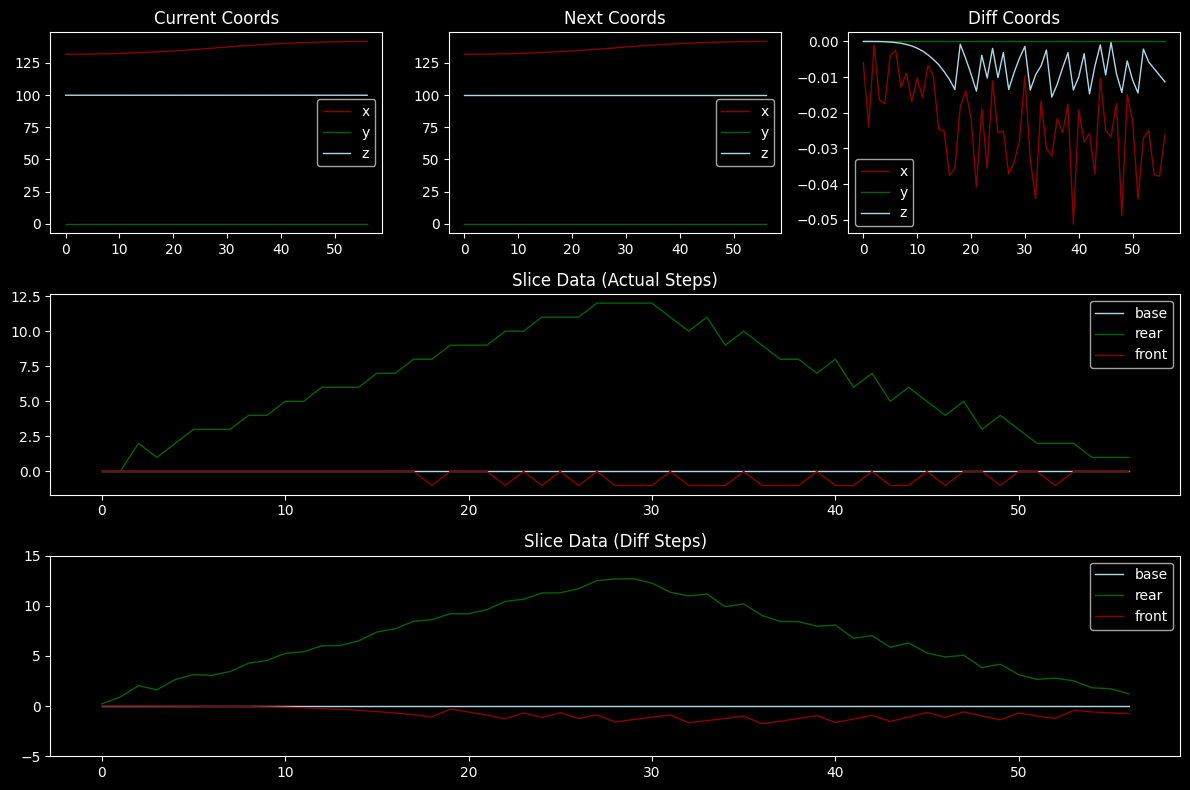

In [3]:
nextPos += (10,0,0)  # adjust for relative movement
dobot.MoveWithSpeed(*nextPos, speed, acceleration)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def circle_points(center, radius, n=100):
    cx, cy = center[:2]
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = cx + radius * np.cos(theta)
    y = cy + radius * np.sin(theta)
    pts = np.column_stack((x, y))
    # combine and repeat the first point at the end
    return np.vstack((pts, pts[0]))

def plot_points(x, y, center):
    plt.figure(figsize=(5,5))
    plt.plot(x, y, marker='o', markersize=4, linestyle='-')   # circle
    plt.scatter(*center, color='red')                    # center
    plt.gca().set_aspect('equal', 'box')                      # equal scaling
    plt.grid(True)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f"Circle center: {tuple(f"{v:.2f}" for v in center[0:2])}, {radius=})")
    plt.show()


radius = 40
pts = circle_points(nextPos, radius, n=20)
x, y = pts[:,0], pts[:,1]
plot_points(x, y, nextPos)

In [ ]:
zPos = nextPos[2] - 9
for pt in pts:
    print(f"Going to {pt} ..")
    dobot.MoveWithSpeed(*pt, zPos, speed, acceleration)

In [ ]:
# back to start pos (center)
dobot.MoveWithSpeed(*nextPos, speed, acceleration)